In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import matplotlib.dates as mdates
import matplotlib.ticker as ticker


superstore = pd.read_csv("superstore.csv")
superstore['Order Date'] = pd.to_datetime(superstore['Order Date'])

yearly_sales = superstore.groupby(superstore["Order Date"].dt.year)["Sales"].sum()
sales = pd.DataFrame({"year":superstore["Order Date"].dt.year.unique(), "sales":yearly_sales})

sales.to_csv('apps/public/yearly_sales.csv')


/var/folders/3_/8bgmkbdj7vz5fh4m_ppttn_c0000gp/T/ipykernel_56973/2807504929.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  superstore['Order Date'] = pd.to_datetime(superstore['Order Date'])


In [3]:
superstore.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,2012-07-31,7/31/12,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,2013-02-05,2/7/13,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,2013-10-17,10/18/13,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,2013-01-28,1/30/13,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,2013-11-05,11/6/13,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [4]:
yearly_sales_by_segment = (
    superstore.groupby([pd.Grouper(key="Order Date", freq="YE"), "Segment"], as_index=False).agg(sales=("Sales", "sum"))
)
yearly_sales_by_segment["Order Date"] = pd.to_datetime(yearly_sales_by_segment["Order Date"])
yearly_sales_by_segment['year'] = yearly_sales_by_segment["Order Date"].dt.year

yearly_sales_by_segment.to_csv('apps/public/yearly_sales_by_segment.csv')

In [7]:
weekly_sales = (
    superstore.groupby([pd.Grouper(key="Order Date", freq="W-MON")], as_index=False).agg(sales=("Sales", "sum"))
)

weekly_sales.to_csv('apps/public/weekly_sales.csv')

In [5]:
weekly_sales_by_segment = (
    superstore.groupby([pd.Grouper(key="Order Date", freq="W-MON"), "Segment"], as_index=False).agg(sales=("Sales", "sum"))
)
weekly_sales_by_segment["Order Date"] = pd.to_datetime(weekly_sales_by_segment["Order Date"])
#weekly_sales_by_segment['week'] = weekly_sales_by_segment["Order Date"].dt.week

weekly_sales_by_segment['truncated'] = weekly_sales_by_segment['sales']/1_000
weekly_sales_by_segment['truncated'] = weekly_sales_by_segment['truncated'].round()

weekly_sales_by_segment.to_csv('apps/public/weekly_sales_by_segment.csv')

In [9]:
daily_sales = (
    superstore.groupby([pd.Grouper(key="Order Date", freq="D")], as_index=False).agg(sales=("Sales", "sum"))
)
daily_sales["Order Date"] = pd.to_datetime(daily_sales["Order Date"])
#weekly_sales_by_segment['week'] = weekly_sales_by_segment["Order Date"].dt.week

daily_sales.to_csv('apps/public/daily_sales.csv')

In [20]:
superstore['Sales'].to_csv('apps/public/raw_sales.csv')

In [ ]:
#superstore['Sales'].hist(bins=100)
import numpy as np

counts, bin_edges = np.histogram(superstore['Sales'], bins=20)

In [12]:
counts

array([49131,  1619,   385,    95,    32,    12,     2,     6,     3,
           2,     0,     0,     1,     0,     0,     1,     0,     0,
           0,     1])

In [13]:
bin_edges

array([4.44000000e-01, 1.13234580e+03, 2.26424760e+03, 3.39614940e+03,
       4.52805120e+03, 5.65995300e+03, 6.79185480e+03, 7.92375660e+03,
       9.05565840e+03, 1.01875602e+04, 1.13194620e+04, 1.24513638e+04,
       1.35832656e+04, 1.47151674e+04, 1.58470692e+04, 1.69789710e+04,
       1.81108728e+04, 1.92427746e+04, 2.03746764e+04, 2.15065782e+04,
       2.26384800e+04])

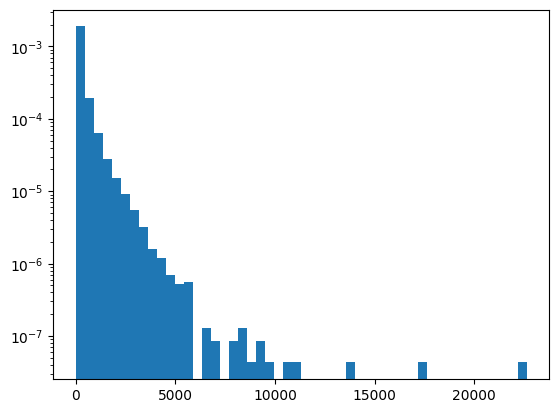

In [24]:
import numpy as np
import matplotlib.pyplot as plt

x, bins, p = plt.hist(superstore[superstore['Sales'] > 0]['Sales'], density=True, log=True, bins=50)
plt.show()

In [22]:
np.min(superstore['Sales'])

np.float64(0.444)

In [6]:
mask = superstore["Order Date"].dt.year == 2014

superstore.loc[mask, ["Order Date", "Sales", "Segment", "Profit"]].to_csv('apps/public/events_2014.csv')

In [ ]:
import plotly.express as px
import numpy as np
from scipy.stats import gaussian_kde
import plotly.graph_objects as go

df = pd.DataFrame({"value":[139,141,141,143,147,148,150,150,151,153,155,156,157,159,163,164,167,171]})

# Create the base histogram
fig = px.histogram(df, x="value", histnorm='probability density', nbins=10)
fig.update_traces(marker_color='rgba(76, 114, 176, 0.5)', marker_line_width=1, marker_line_color="black")

# Kernel Density Estimate
kde = gaussian_kde(df['value'])
x_range = np.linspace(min(df['value']), max(df['value']), 100)
y_density = kde(x_range)

# KDE as trace
curve = go.Scatter(
    x=x_range,
    y=y_density,
    mode='lines',
    name='Density Estimate',
    line=dict(color='red', width=2),
    line_shape='spline' # Optional: can apply slight smoothing to the line itself
)
fig.add_trace(curve)

# Update layout for clarity
fig.update_layout(
    title="Heights of students",
    xaxis_title="Heights",
    yaxis_title="Density",
    showlegend=True
)

fig.show()
